In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_train_final, X_test_final, y_train, y_test = joblib.load('../data/processed/train_test_split.pkl')
print(X_train_final.shape, X_test_final.shape)

(4184904, 14) (1046226, 14)


In [5]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

xgb_model = XGBClassifier(
    n_estimators=100, 
    max_depth=6,
    learning_depth=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_final, y_train)

y_pred_xgb = xgb_model.predict(X_test_final)
y_proba_xgb = xgb_model.predict_proba(X_test_final)[:, 1]


print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("AUC-ROC:", roc_auc_score(y_test, y_proba_xgb))

scale_pos_weight: 4.41


c:\Users\hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:25:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:793: 
Parameters: { "learning_depth" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6276244329619031
Precision: 0.2809301183847896
Recall: 0.651424047357854
F1 Score: 0.39256463148244297
AUC-ROC: 0.6897792636375377


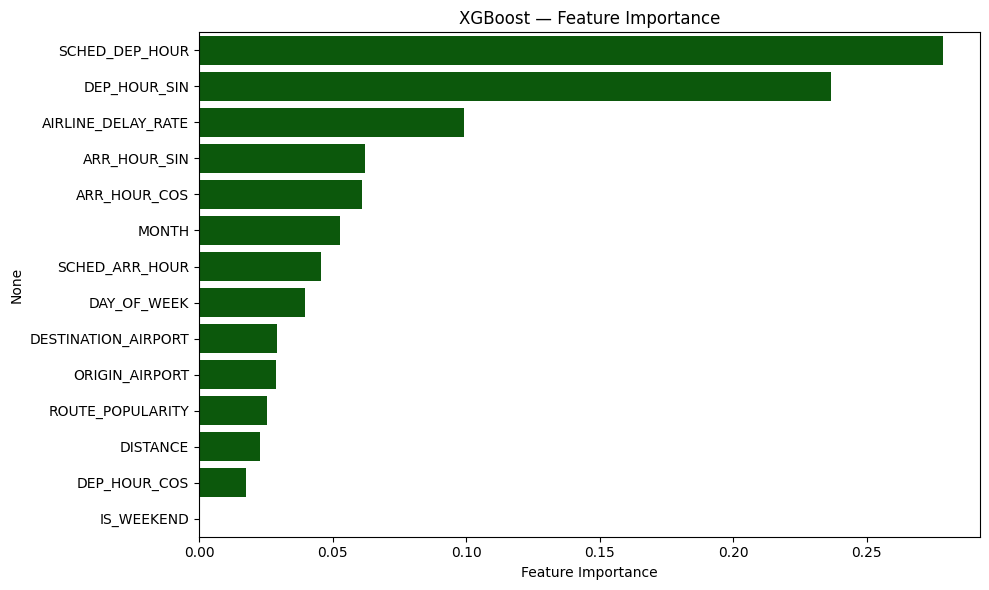

SCHED_DEP_HOUR         0.278542
DEP_HOUR_SIN           0.236847
AIRLINE_DELAY_RATE     0.099109
ARR_HOUR_SIN           0.062220
ARR_HOUR_COS           0.061047
MONTH                  0.052900
SCHED_ARR_HOUR         0.045616
DAY_OF_WEEK            0.039646
DESTINATION_AIRPORT    0.029357
ORIGIN_AIRPORT         0.028929
ROUTE_POPULARITY       0.025402
DISTANCE               0.022881
DEP_HOUR_COS           0.017503
IS_WEEKEND             0.000000
dtype: float32


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_train_final.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_xgb.values, y=importances_xgb.index, color='darkgreen')
plt.xlabel('Feature Importance')
plt.title('XGBoost — Feature Importance')
plt.tight_layout()
plt.savefig('../reports/figures/xgb_feature_importance.png', dpi=150)
plt.show()

print(importances_xgb)

In [8]:
joblib.dump(xgb_model, '../src/xgboost_model.pkl')
print("Saved!")

Saved!
